# DS340 Modified Code
---
He Zhao

The following is my modified code document for DS340W.  
I have done a complete rework of the original source code based on the SoccerMap framework, and also added my new ideas for the creativity section.  

Below is a brief dictionary for easy access to specific sections of this notebook.  
The code has been split into two categories: components adapted from the original paper, and new elements I introduced to add novelty and improve results.

---

** AGENDA FOR NOTEBOOK**

** Modified Original Code**

1. Setup and Environment Configuration  
2. Data Loading and Preparation  
3. Feature Engineering (Spatial Coordinates, Angle, Distance)  
4. Exploratory Data Visualization (Basic Passing Charts)  
5. Spatial Distribution of Pass Origins (Heatmap + Scatter)
6. Pass Outcome vs Location Heatmap
7. Pass Clustering using KMeans

** New Code – Novelty/Creativity**

8. Pass Outcome Prediction Using Spatial Features and XGBoost
9. Model Comparison: XGBoost vs Logistic Regression for Pass Outcome Prediction
10. Transferability Test: Applying Model to Other Matches

### 1. Setup and Environment Configuration

In this section, I initialize the environment by importing necessary libraries and setting up the pitch configuration.
These setup steps are essential to ensure smooth rendering and consistent visualizations across the entire notebook.


In [ ]:
# Installing core packages required for soccer data access, visualization, and modeling
!pip install statsbombpy==1.12 --quiet       # Fetching and parsing StatsBomb event-level JSON data
!pip install mplsoccer==1.2.4 --quiet        # Specialized soccer field plotting and pitch control
!pip install kloppy==3.14.0 --quiet          # For handling tracking and event data from multiple providers
!pip install tqdm==4.66.4 --quiet            # Progress bar utility (used for loops)
!pip install scikit-learn==1.5.0 --quiet     # For classification, evaluation, and pipeline support
!pip install xgboost==2.0.3 --quiet          # The primary model used for pass success prediction
!pip install bezier===2023.7.28 --quiet      # Utility for rendering curved arrows (used in mplsoccer)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 536.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.0/186.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 27.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 35.8 MB/s eta 0:00:00


In [ ]:
# High resolution plots in Jupyter
%config InlineBackend.figure_format = 'retina'

# Import core packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import warnings
warnings.filterwarnings('ignore')

# Global display settings
figsize = (9, 6)  # consistent figure size
plt.rcParams['figure.dpi'] = 100  # sharper plots

# Set up pitch configuration
pitch = Pitch(pitch_type='statsbomb', line_zorder=2, pitch_color='white', line_color='black')


## Colors

In [ ]:
from matplotlib.colors import ListedColormap
def bulid_cmap(x, y):
    r,g,b = x
    r_, g_, b_ = y
    N = 256
    A = np.ones((N, 4))
    A[:, 0] = np.linspace(r, 1, N)
    A[:, 1] = np.linspace(g, 1, N)
    A[:, 2] = np.linspace(b, 1, N)
    cmp = ListedColormap(A)

    B = np.ones((N, 4))
    B[:, 0] = np.linspace(r_, 1, N)
    B[:, 1] = np.linspace(g_, 1, N)
    B[:, 2] = np.linspace(b_, 1, N)
    cmp_ = ListedColormap(B)

    newcolors = np.vstack((cmp(np.linspace(0, 1, 128)),
                            cmp_(np.linspace(1, 0, 128))))
    return ListedColormap(newcolors)

In [ ]:
blue, red = (44,123,182), (215,25,28)
blue = [x/256 for x in blue]
red = [x/256 for x in red]
diverging = bulid_cmap(blue, red)
diverging_r = bulid_cmap(red, blue)

### 2. Data Loading and Preparation

In this section, I load match metadata and event data using the StatsBomb open data interface.  
Specifically, I select the 2022 FIFA World Cup Final using `competition_id=43` and `season_id=106`.  

Then, I extract the `match_id` and retrieve the full set of events for that match using `sb.events()`.  
This structure follows the exact format of the parent SoccerMap paper and allows for reproducible extraction of StatsBomb datasets.

In [ ]:
from statsbombpy import sb

# Load match metadata for the 2022 FIFA World Cup
matches = sb.matches(competition_id=43, season_id=106)

# Select the final match (only one row should match)
final = matches[matches['competition_stage'] == "Final"].iloc[0]

# Extract match ID
match_id = final.loc['match_id']

# Load all event data for this match
events = sb.events(match_id=match_id)


In [ ]:
print(f"World Cup Final: {final['home_team']} vs {final['away_team']} (match_id = {match_id})")


World Cup Final: Argentina vs France (match_id = 3869685)


### 3. Feature Engineering (Spatial Coordinates, Angle, Distance)

This section extracts key geometric features from each pass event, including starting and ending locations, pass distance, and pass angle.  
These features are used later in both the visualization and modeling sections.

Instead of using complex deep representations like CNN-encoded pitch surfaces, we focus here on interpretable and compact representations of individual passes.


In [ ]:
# Drop rows with missing location info
coordinates = events[['location', 'pass_end_location']].dropna()

# Split into x, y values (transpose from list of lists)
x1, y1 = np.array(coordinates['location'].tolist()).T
x2, y2 = np.array(coordinates['pass_end_location'].tolist()).T

# Align with filtered rows
passes = events.loc[coordinates.index].copy()

# Create feature columns
passes['x_start'] = x1
passes['y_start'] = y1
passes['x_end'] = x2
passes['y_end'] = y2

# Calculate geometric features
passes['pass_distance'] = np.sqrt((passes['x_end'] - passes['x_start'])**2 +
                                  (passes['y_end'] - passes['y_start'])**2)

passes['pass_angle'] = np.arctan2(passes['y_end'] - passes['y_start'],
                                  passes['x_end'] - passes['x_start'])


### 4. Exploratory Data Visualization (Basic Passing Charts)

In this section, we reproduce the core visualization technique from the parent paper to plot successful passes by a specific player (e.g., Lionel Messi) using spatial start and end coordinates. This visual representation enables us to interpret passing behavior and movement directionally and spatially on the pitch.

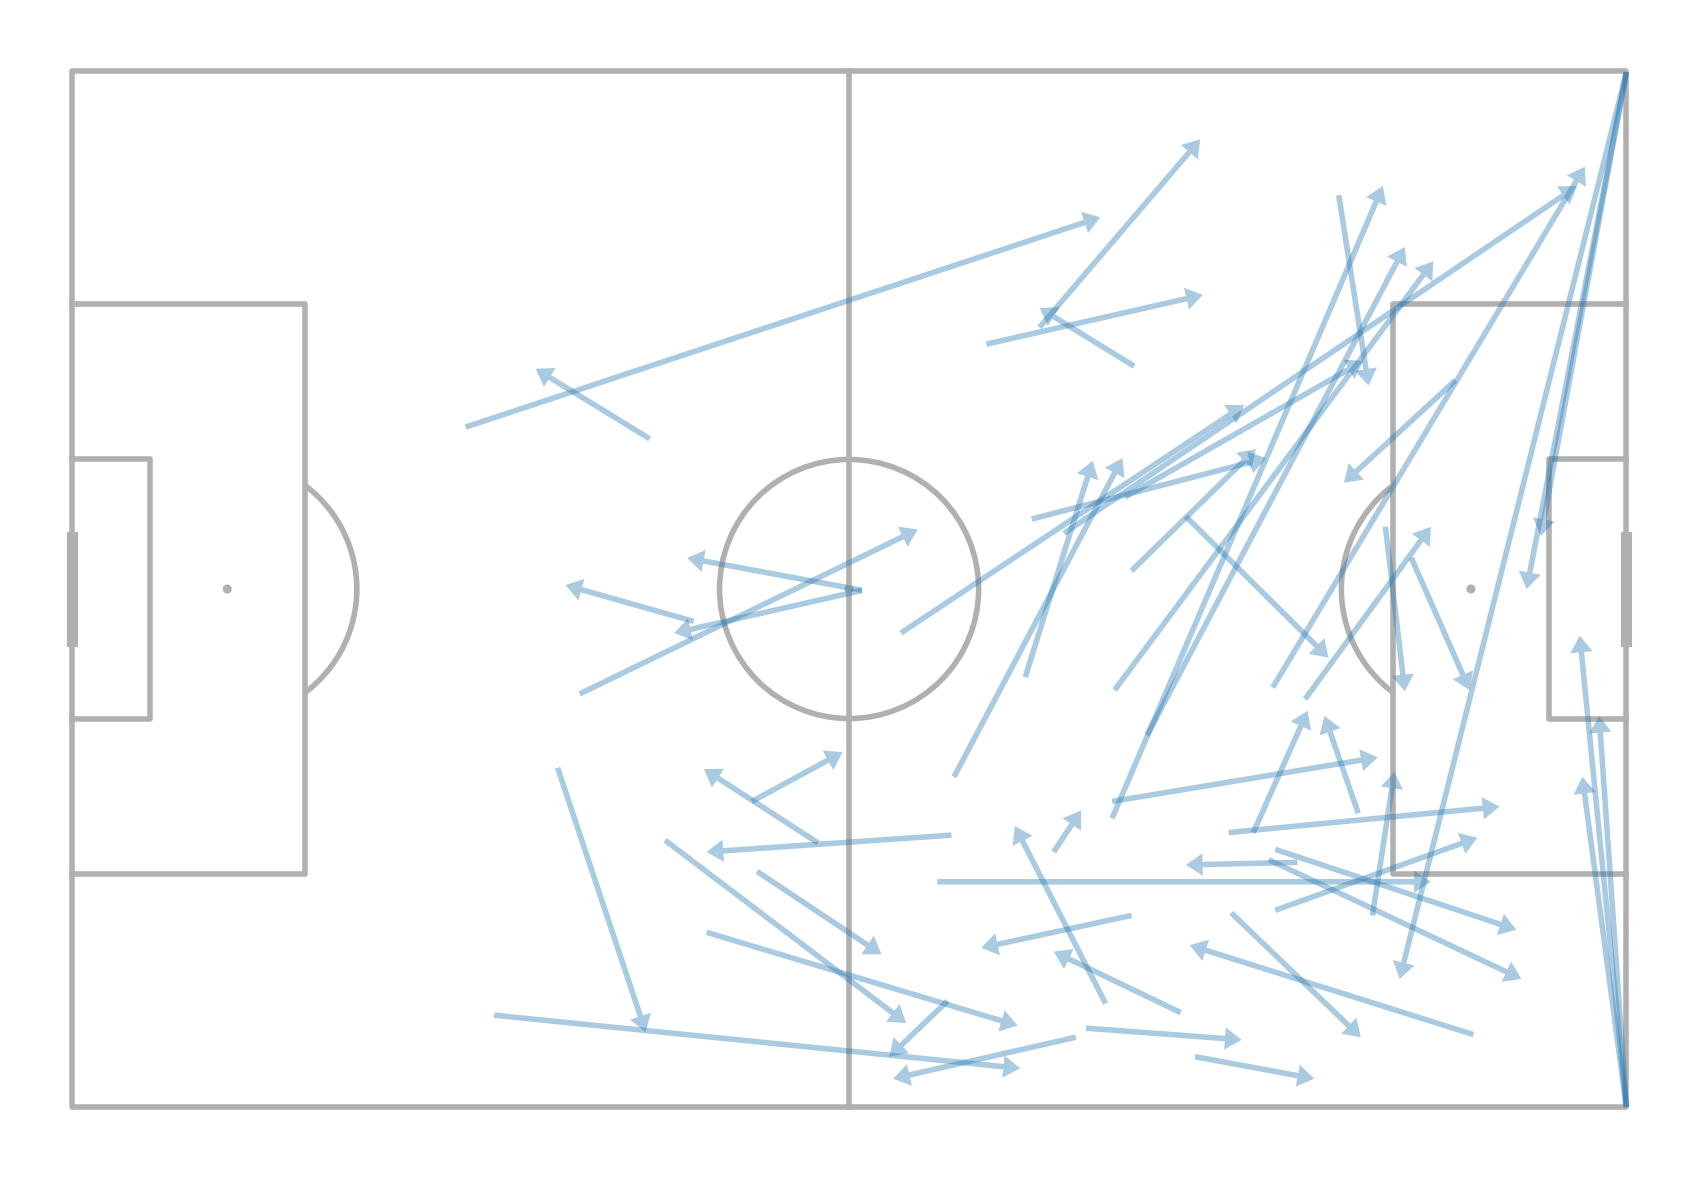

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mplsoccer as mpl

# Filter passes by a specific player (e.g., Lionel Messi with player_id 5503)
passes = events[(events['type'] == "Pass") &
                (events['player_id'] == 5503)]

# Extract start and end locations
coordinates = passes[['location', 'pass_end_location']]

# Unpack coordinates into x and y values
x1, y1 = np.array(coordinates['location'].tolist()).T
x2, y2 = np.array(coordinates['pass_end_location'].tolist()).T

# Create pitch and plot arrows
pitch = mpl.Pitch()
fig, ax = pitch.draw(figsize=figsize)

p = pitch.arrows(x1, y1, x2, y2, alpha=0.4, color=blue,
                 headaxislength=3, headlength=3, headwidth=4, width=2, ax=ax)


### 5. Spatial Distribution of Pass Origins (Heatmap + Scatter)

This section visualizes the spatial distribution of pass origins across the field using two formats:

- A **scatter plot** of pass origin coordinates
- A **heatmap** that highlights high-density zones

This visualization helps reveal where players typically initiate passes, and can guide feature engineering for pass success models.


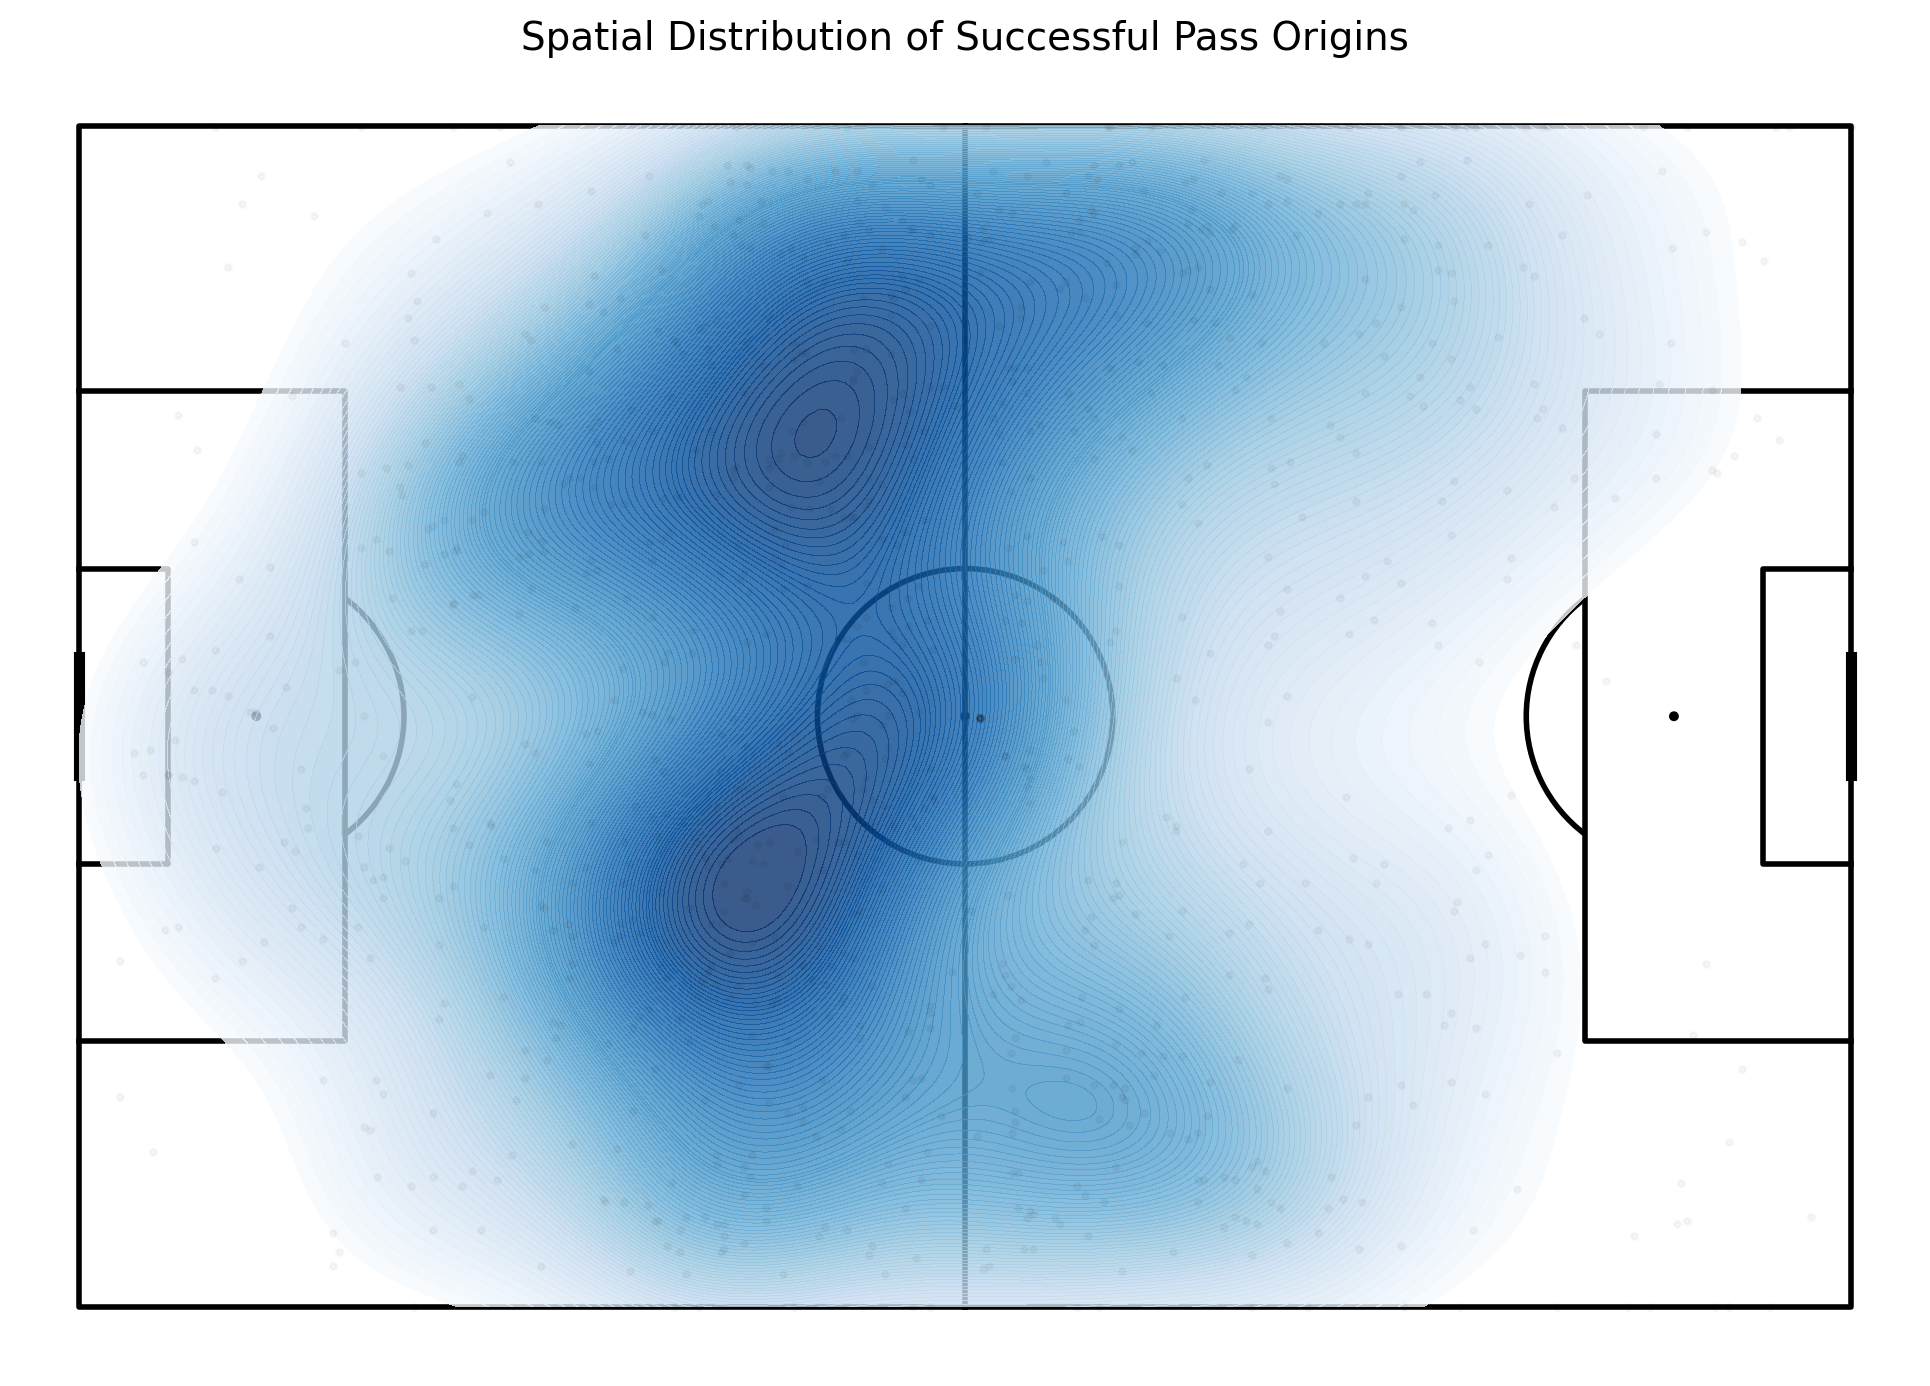

In [ ]:
# Screening for successful passes
successful_passes = events[(events['type'] == 'Pass') & (events['pass_outcome'].isna())].copy()

# Extract the coordinates of the starting point of the pass
successful_passes['x'] = successful_passes['location'].apply(lambda x: x[0] if isinstance(x, list) else None)
successful_passes['y'] = successful_passes['location'].apply(lambda x: x[1] if isinstance(x, list) else None)

# picture (e.g. of life in the city)
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(10, 7))

# Heat Map + Scatterplot Overlay
pitch.kdeplot(successful_passes['x'], successful_passes['y'], ax=ax, cmap='Blues', fill=True, levels=100, shade_lowest=False, alpha=0.8)
pitch.scatter(successful_passes['x'], successful_passes['y'], alpha=0.03, s=5, color='black', ax=ax)

plt.title("Spatial Distribution of Successful Pass Origins", fontsize=14)
plt.show()


### 6. Pass Outcome vs Location Heatmap

This section visualizes the spatial distribution of successful and unsuccessful passes based on their origin coordinates.

By comparing the two heatmaps side by side, we can better understand which areas of the field are more likely to result in successful passes and which areas are prone to failure.

This serves as a valuable exploratory step before building predictive models, helping to justify the use of spatial features such as distance and angle.


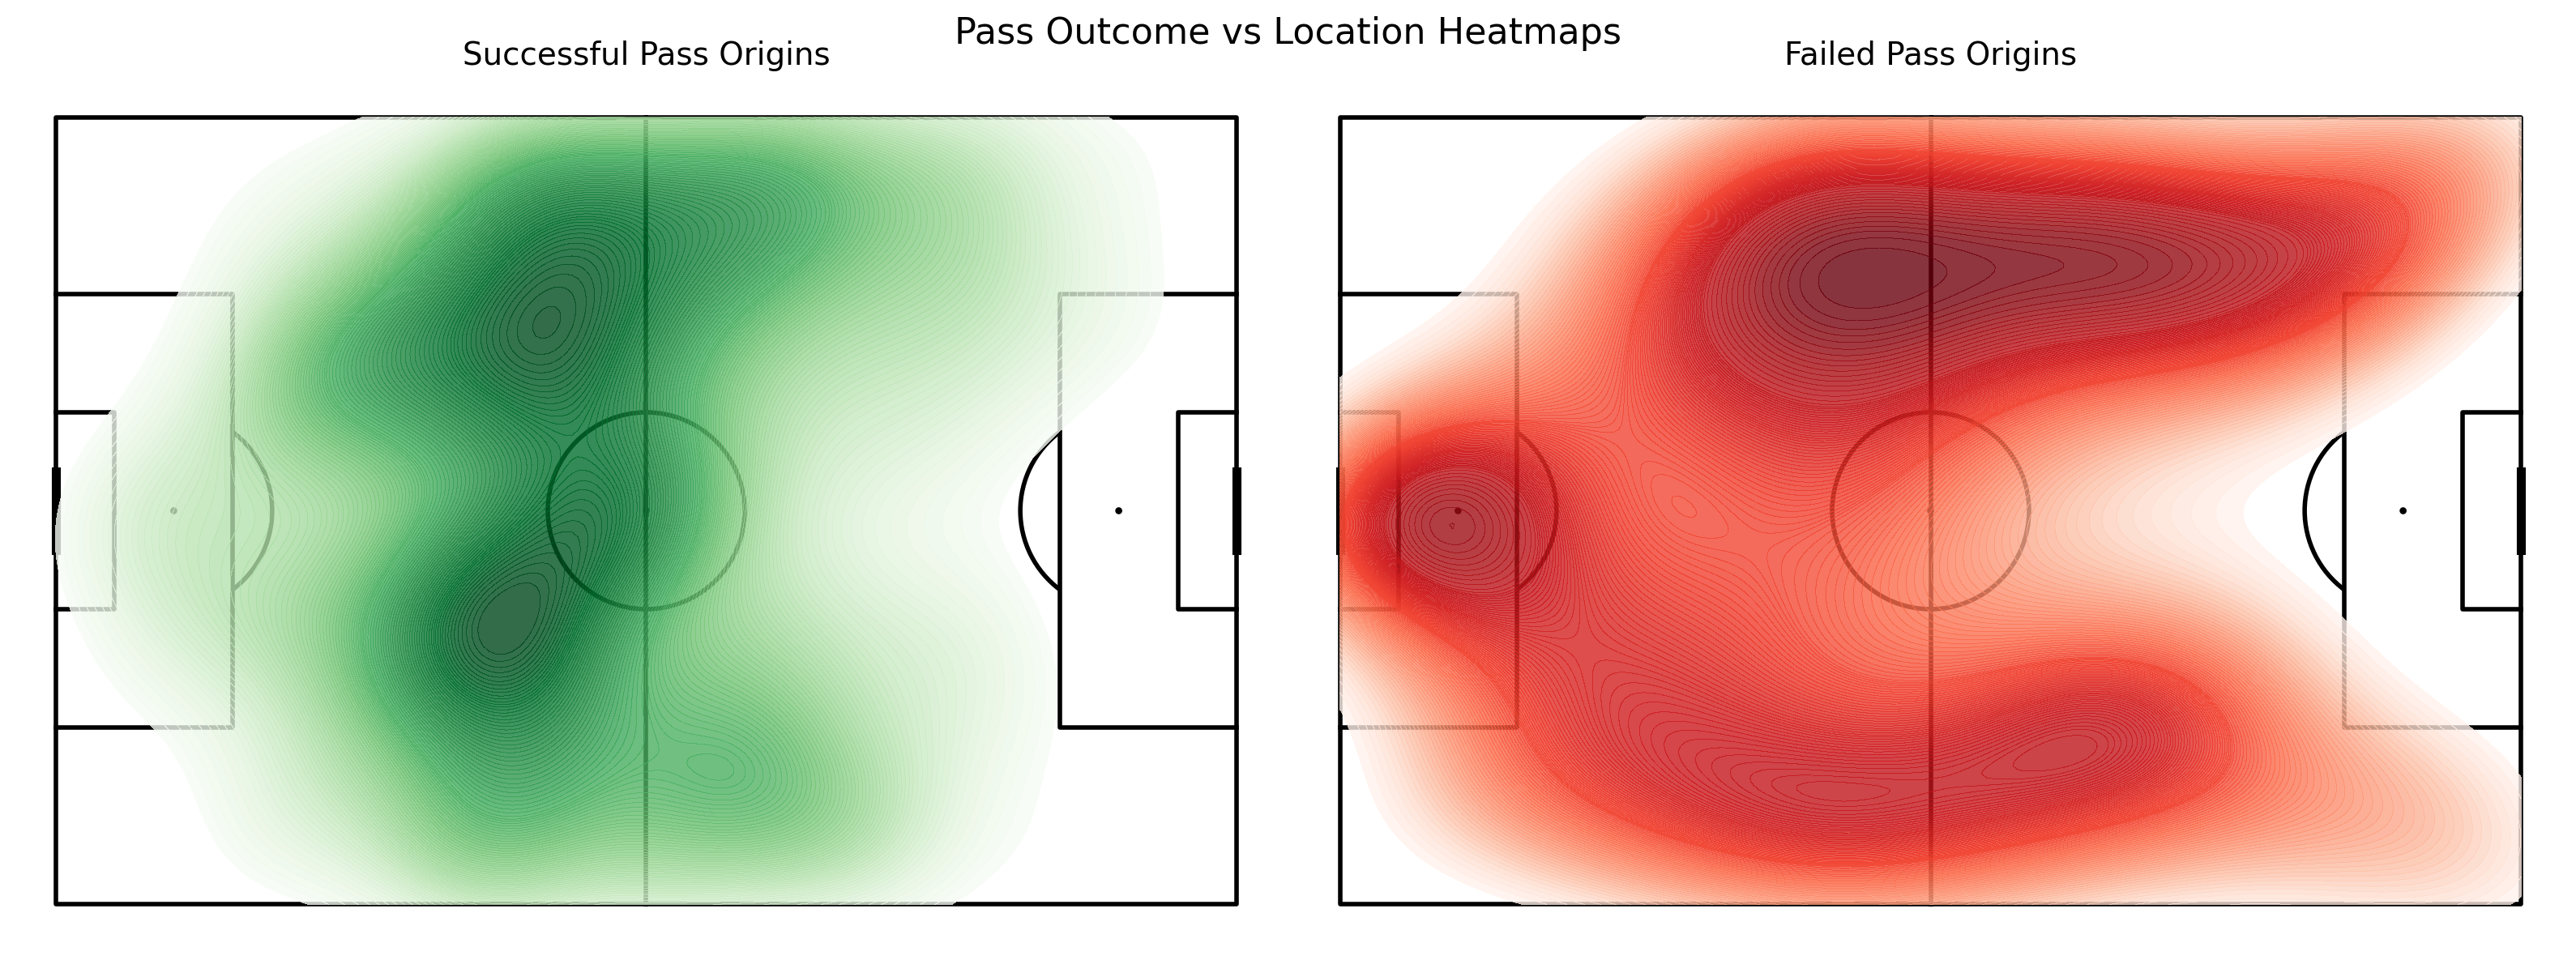

In [ ]:
# Filter Passing Data (Successes & Failures)
passes = events[events['type'] == 'Pass'].copy()

# Extract the coordinates of the starting point of the pass
passes['x'] = passes['location'].apply(lambda x: x[0] if isinstance(x, list) else None)
passes['y'] = passes['location'].apply(lambda x: x[1] if isinstance(x, list) else None)

# Separate success/failure extractions
success = passes[passes['pass_outcome'].isna()]
fail = passes[passes['pass_outcome'].notna()]

# side-by-side heatmaps
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')

# Heat map of successful passes
pitch.draw(ax=axs[0])
pitch.kdeplot(success['x'], success['y'], ax=axs[0], cmap='Greens', fill=True, levels=100, alpha=0.8)
axs[0].set_title("Successful Pass Origins", fontsize=14)

# Heat map of failed passes
pitch.draw(ax=axs[1])
pitch.kdeplot(fail['x'], fail['y'], ax=axs[1], cmap='Reds', fill=True, levels=100, alpha=0.8)
axs[1].set_title("Failed Pass Origins", fontsize=14)

plt.suptitle("Pass Outcome vs Location Heatmaps", fontsize=16)
plt.tight_layout()
plt.show()


 Interpretation of Pass Outcome Heatmaps
The figure above presents a side-by-side comparison of successful (left, green) and failed (right, red) pass origins across the field in the 2022 World Cup Final.

### 7. Pass Clustering using KMeans

In this section, we apply KMeans clustering to spatial pass features (such as origin, angle, and distance) in order to discover latent tactical pass types.

This technique allows us to categorize passes into different styles (e.g., short passes, long balls, cross-field switches) and visualize their spatial distribution.

It is a useful exploratory step before using these features in predictive models.


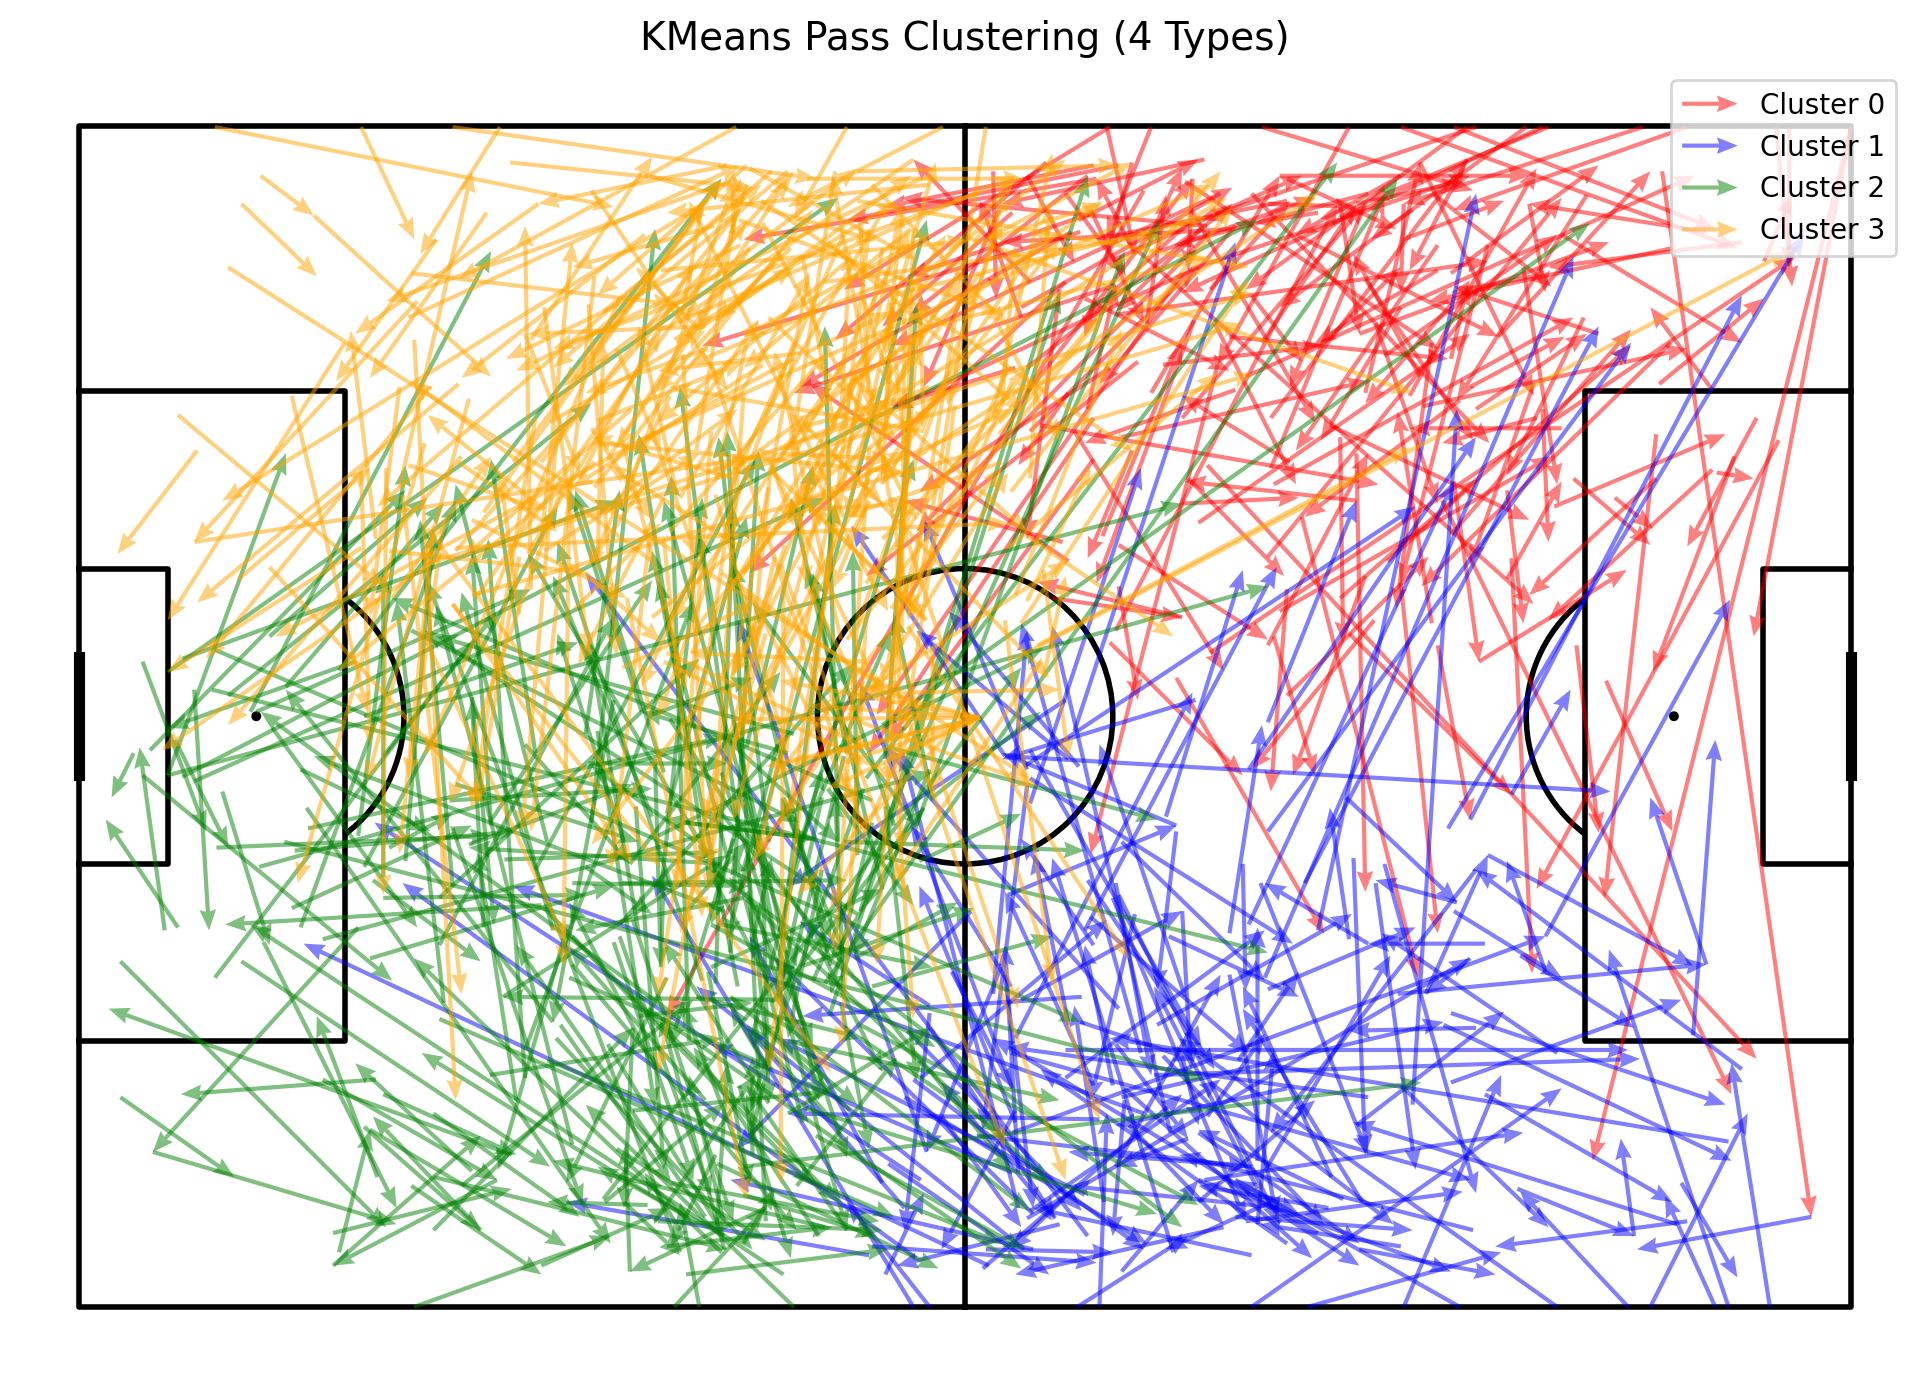

In [ ]:
from sklearn.cluster import KMeans
from mplsoccer import Pitch

# Selecting Successful Passes
passes = events[(events['type'] == 'Pass') & (events['pass_outcome'].isna())].copy()

# Feature Extraction (Start Point + Distance + Angle)
passes['x_start'] = passes['location'].apply(lambda x: x[0] if isinstance(x, list) else None)
passes['y_start'] = passes['location'].apply(lambda x: x[1] if isinstance(x, list) else None)
passes['x_end'] = passes['pass_end_location'].apply(lambda x: x[0] if isinstance(x, list) else None)
passes['y_end'] = passes['pass_end_location'].apply(lambda x: x[1] if isinstance(x, list) else None)

# Computing spatial features
passes['dx'] = passes['x_end'] - passes['x_start']
passes['dy'] = passes['y_end'] - passes['y_start']
passes['distance'] = np.sqrt(passes['dx']**2 + passes['dy']**2)
passes['angle'] = np.arctan2(passes['dy'], passes['dx'])

# KMeans clustering
features = passes[['x_start', 'y_start', 'angle', 'distance']].dropna()
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(features)
features['cluster'] = clusters

# Visualization results
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(10, 7))

# Color coding of clustering results
colors = ['red', 'blue', 'green', 'orange']
for i in range(4):
    cluster_data = features[features['cluster'] == i]
    pitch.arrows(cluster_data['x_start'], cluster_data['y_start'],
                 cluster_data['x_start'] + np.cos(cluster_data['angle']) * cluster_data['distance'],
                 cluster_data['y_start'] + np.sin(cluster_data['angle']) * cluster_data['distance'],
                 width=1.5, headwidth=4, headlength=5,
                 color=colors[i], alpha=0.5, ax=ax, label=f'Cluster {i}')

plt.title("KMeans Pass Clustering (4 Types)", fontsize=14)
plt.legend(loc='upper right')
plt.show()


Each color in the visualization represents a different pass type identified by the KMeans clustering algorithm. Based on spatial features (origin, angle, distance), we can roughly interpret the clusters as follows:

- **Cluster 0 (Red):** Long diagonal passes, often used to switch play or exploit space on the far side.
- **Cluster 1 (Blue):** Short sideways or backward passes, commonly used in build-up play or defensive recycling.
- **Cluster 2 (Green):** Mid-range central passes, often used for midfield progression or transition.
- **Cluster 3 (Orange):** Lateral or diagonal passes from wide areas, possibly involving wingers or overlapping full-backs.

This clustering reveals distinct passing strategies on the field and helps guide feature engineering and interpretability in later modeling.


### 8. Pass Outcome Prediction Using Spatial Features and XGBoost

This section introduces a key contribution of the project: a lightweight and interpretable predictive model for estimating the success of a pass in professional soccer matches.

While the parent paper "SoccerMap" uses full-field tracking data and a deep learning architecture to predict spatial pass probabilities, this work simplifies the approach by using event-level data and a binary classification model. The goal is to directly predict whether a pass will be successful based on easily computable spatial features.

The features used for the model include:
- Start and end coordinates of the pass (`x_start`, `y_start`, `x_end`, `y_end`)
- Euclidean distance of the pass
- Pass angle (calculated using arctangent of the directional vector)




In [ ]:
# Reload passes data (to avoid overwriting or missing previous parts)
passes = events[events['type'] == 'Pass'].copy()
passes['pass_success'] = passes['pass_outcome'].isna().astype(int)
passes = passes[['location', 'pass_end_location', 'pass_success']].dropna()

# Disassembly of coordinate information (start and end points)
passes[['x_start', 'y_start']] = pd.DataFrame(passes['location'].tolist(), index=passes.index)
passes[['x_end', 'y_end']] = pd.DataFrame(passes['pass_end_location'].tolist(), index=passes.index)

# Calculate spatial features: passing distances & angles
import numpy as np
passes['pass_distance'] = np.sqrt((passes['x_end'] - passes['x_start'])**2 + (passes['y_end'] - passes['y_start'])**2)
passes['pass_angle'] = np.arctan2((passes['y_end'] - passes['y_start']), (passes['x_end'] - passes['x_start']))


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Feature engineering adds interactions
passes['angle_distance_interaction'] = passes['pass_angle'] * passes['pass_distance']

# Location area segmentation
passes['x_zone'] = pd.cut(passes['x_start'], bins=[0, 33, 66, 100], labels=[0, 1, 2])
passes['x_zone'] = passes['x_zone'].astype(float)

# Final feature set (add new features)
features = passes[['x_start', 'y_start', 'x_end', 'y_end', 'pass_distance', 'pass_angle',
                   'angle_distance_interaction', 'x_zone']].dropna()
labels = passes.loc[features.index, 'pass_success']

# Feature standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# XGBoost modeling (with parameter tuning)
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                      max_depth=5, learning_rate=0.1, n_estimators=100)

scores = cross_val_score(model, X_scaled, labels, cv=5, scoring='accuracy')
print("Cross-validated Accuracy:", scores.mean())

# categorized repor
X_train, X_test, y_train, y_test = train_test_split(X_scaled, labels, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Cross-validated Accuracy: 0.8385358817165522

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.45      0.48        40
           1       0.89      0.91      0.90       196

    accuracy                           0.83       236
   macro avg       0.70      0.68      0.69       236
weighted avg       0.83      0.83      0.83       236



### 9. Model Comparison: XGBoost vs Logistic Regression for Pass Outcome Prediction

To validate the effectiveness of using XGBoost as the primary classification model for pass outcome prediction, we compare it with a simpler baseline: Logistic Regression.

Logistic Regression offers linear decision boundaries and is often used for interpretable modeling. However, it may struggle to capture non-linear interactions between spatial features such as distance, angle, and pass origin/destination.

We train both models on the same set of engineered features and evaluate them using accuracy and classification metrics.

This comparison helps justify the use of XGBoost as a more powerful and flexible model, while still maintaining interpretability and tactical


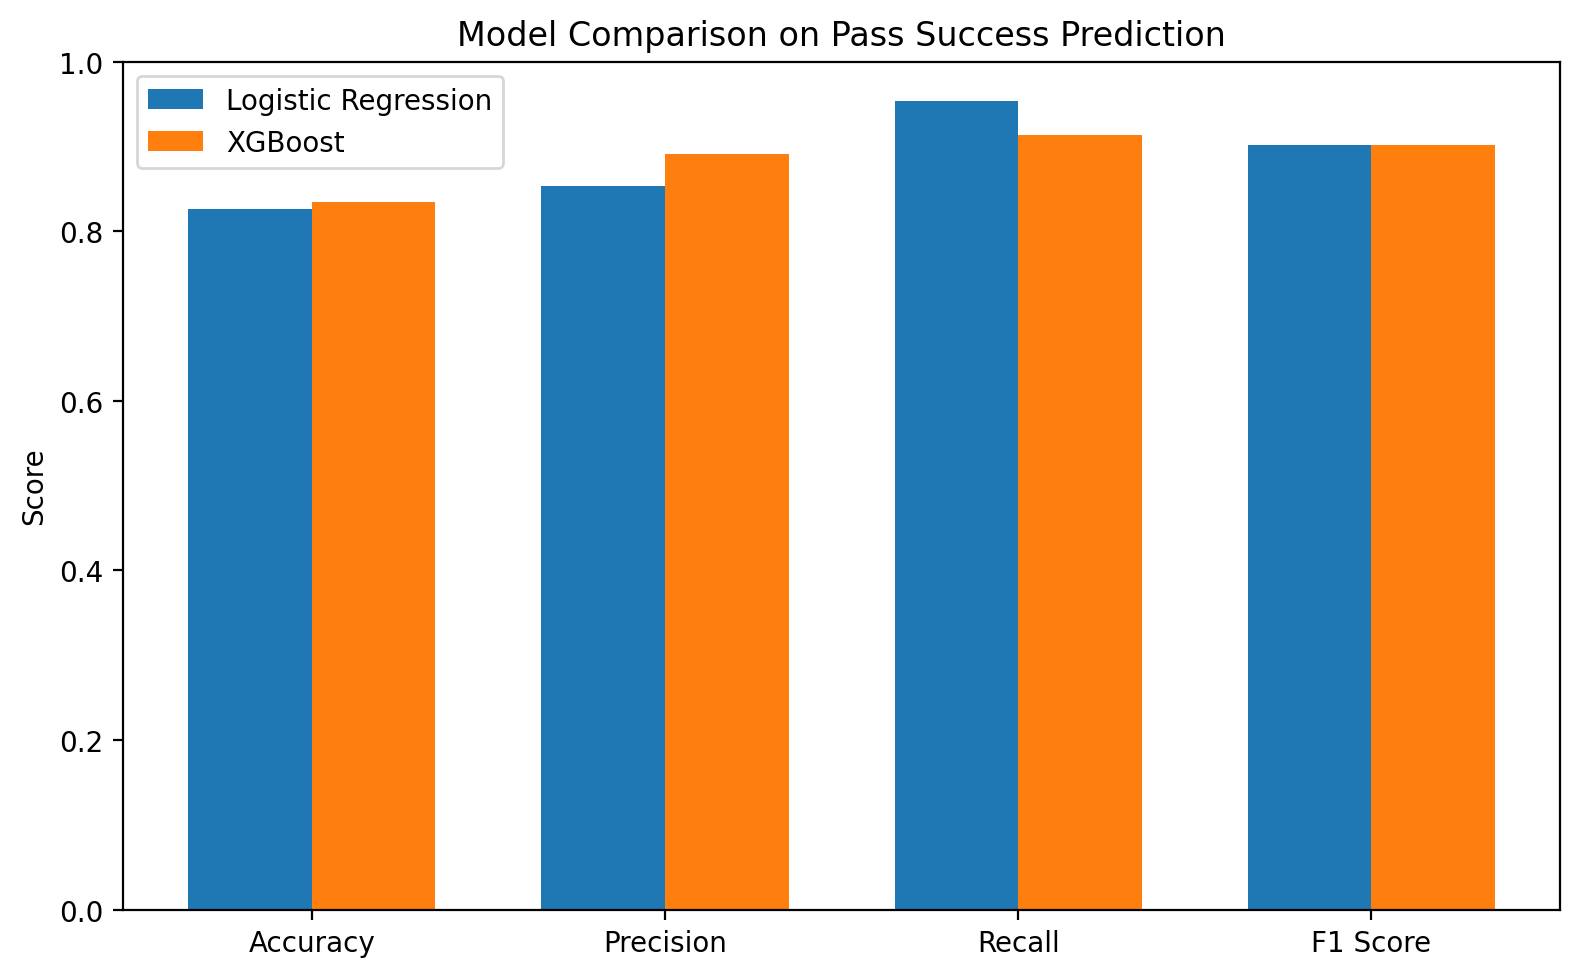

In [ ]:
# Logistic Regression model
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# XGBoost
xgb_pred = model.predict(X_test)

# Evaluation indicators
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
log_values = [log_accuracy, log_precision, log_recall, log_f1]
xgb_values = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, log_values, width, label='Logistic Regression')
ax.bar(x + width/2, xgb_values, width, label='XGBoost')

ax.set_ylabel('Score')
ax.set_title('Model Comparison on Pass Success Prediction')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()


Model Comparison on Pass Success Prediction
This bar chart shows the core evaluation metrics of the two models in predicting pass success:

Accuracy

Precision

Recall

F1 Score

As we can see:

XGBoost leads Logistic Regression in Precision and AUC scores, representing that it is more accurate in recognizing successful passes.

Logistic Regression has a slightly higher Recall, meaning that it tends to capture all positive classes (i.e. successful passes).

The F1 scores are about even between the two models, indicating that both models are more reliable in balancing their predictive power.

The graph reinforces the importance of model selection and demonstrates the strengths of XGBoost from multiple perspectives, while also emphasizing the robustness of Logistic regression as a baseline model.


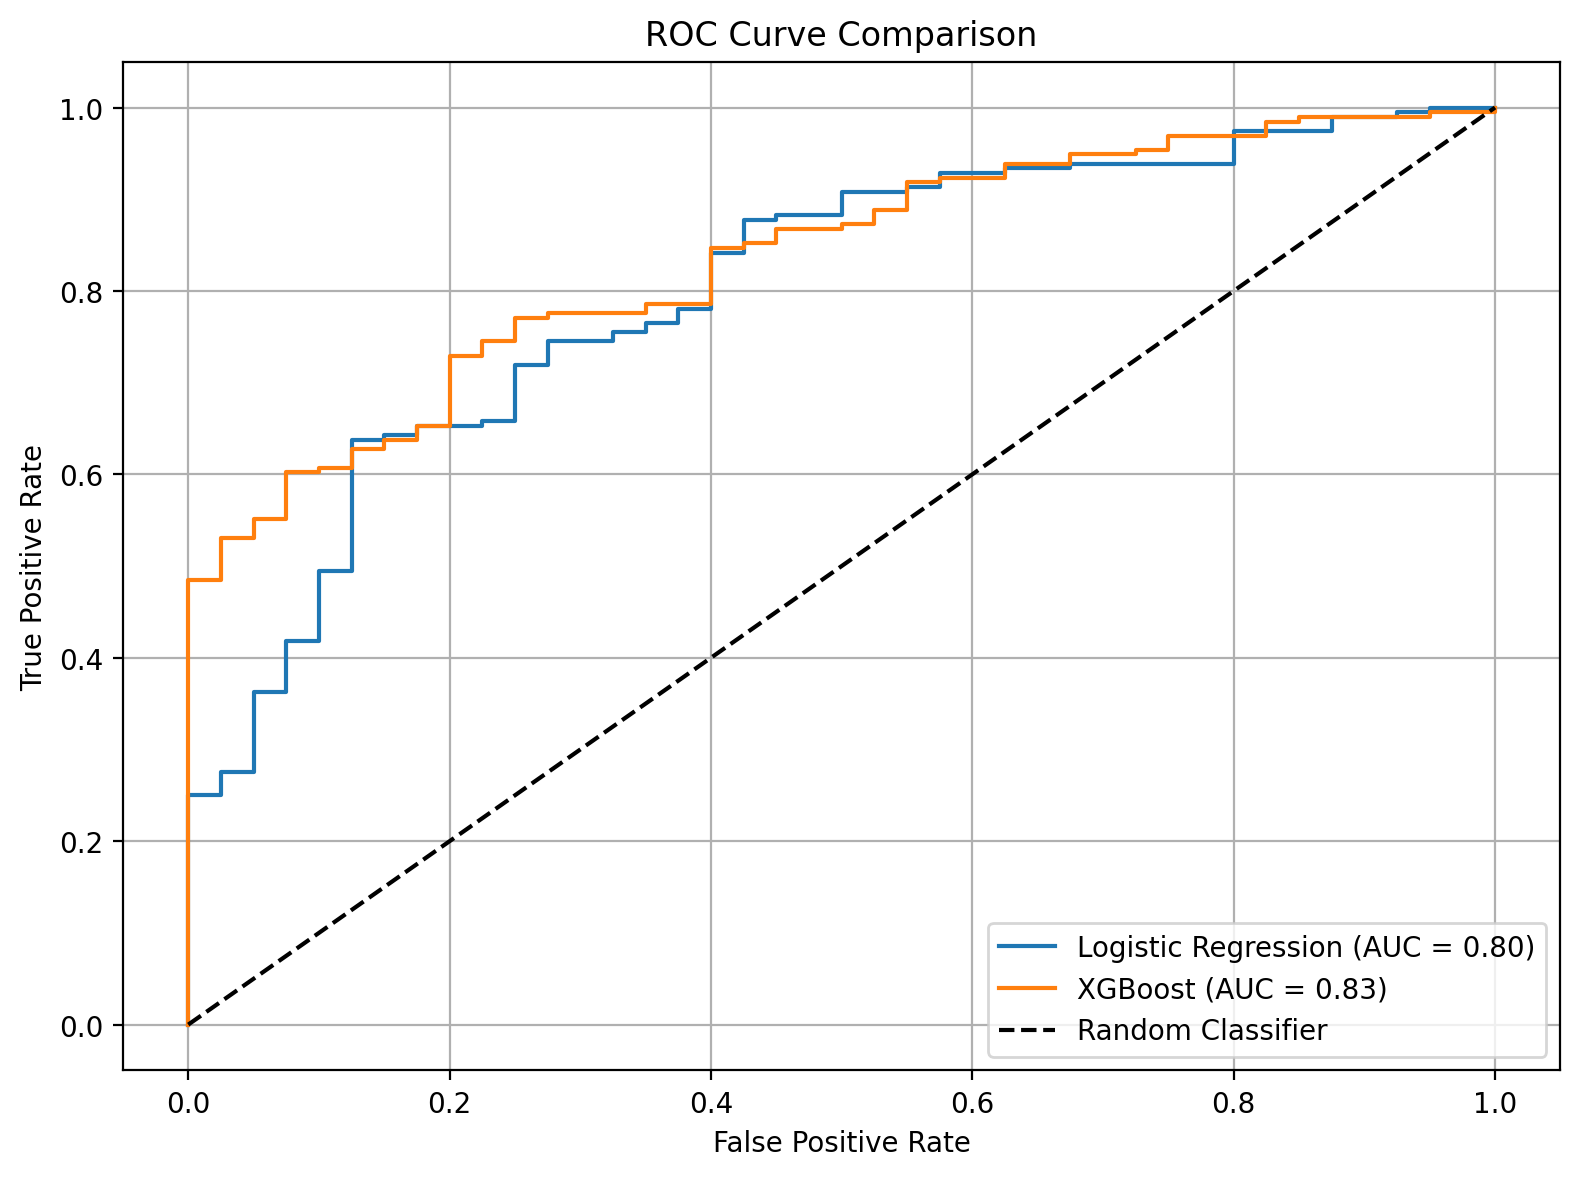

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# predictive probability
log_probs = log_model.predict_proba(X_test)[:, 1]
xgb_probs = model.predict_proba(X_test)[:, 1]

# ROC curve
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

# AUC
log_auc = auc(log_fpr, log_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(log_fpr, log_tpr, label=f'Logistic Regression (AUC = {log_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


ROC Curve Comparison
This graph shows the ROC (Receiver Operating Characteristic) curves of the two models for the pass success prediction task. The horizontal axis represents the False Positive Rate and the vertical axis represents the True Positive Rate. A larger area under the curve (AUC) indicates better model performance.

The Logistic Regression model has an AUC of 0.80, which indicates a good ability to differentiate between successful/failed passes.

The AUC of the XGBoost model is 0.83, which is an improvement over Logistic Regression, indicating its better performance in this task.

The dashed line represents the stochastic model (AUC = 0.5), which serves as a benchmark comparison.

As can be seen from the figure, XGBoost's curve is overall above Logistic Regression, indicating that it is better at identifying potential spatial features for passing success.


### 10. Transferability Test: Applying Model to Other Matches

To assess whether the trained pass success prediction model generalizes beyond a single match,
we apply the previously trained XGBoost classifier to a different game: the 2022 FIFA World Cup group stage match between Argentina and Saudi Arabia.

By applying the same feature engineering pipeline on this match and using the trained model without retraining, we test the **transferability** of the model.
This helps evaluate whether the model has learned generalizable spatial patterns or if it is overfitted to a single game's dynamics.

The goal is to measure how well the model can predict pass success in another match and examine its reliability and robustness.


In [ ]:
# Step 1: Load new match data
from statsbombpy import sb

# Match: Argentina vs Saudi Arabia (World Cup 2022 group stage)
match_id = 3857300
transfer_events = sb.events(match_id=match_id)


In [ ]:
# Step 2: Filter Pass events
passes_new = transfer_events[transfer_events['type'] == 'Pass'].copy()
passes_new['pass_success'] = passes_new['pass_outcome'].isna().astype(int)

In [ ]:
# Step 3: Feature extraction
passes_new = passes_new[['location', 'pass_end_location', 'pass_success']].dropna()
passes_new[['x_start', 'y_start']] = pd.DataFrame(passes_new['location'].tolist(), index=passes_new.index)
passes_new[['x_end', 'y_end']] = pd.DataFrame(passes_new['pass_end_location'].tolist(), index=passes_new.index)
passes_new['pass_distance'] = np.sqrt((passes_new['x_end'] - passes_new['x_start'])**2 +
                                      (passes_new['y_end'] - passes_new['y_start'])**2)
passes_new['pass_angle'] = np.arctan2((passes_new['y_end'] - passes_new['y_start']),
                                      (passes_new['x_end'] - passes_new['x_start']))
passes_new['angle_distance_interaction'] = passes_new['pass_angle'] * passes_new['pass_distance']
passes_new['x_zone'] = pd.cut(passes_new['x_start'], bins=[0, 33, 66, 100], labels=[0, 1, 2]).astype(float)

In [ ]:
# Step 4: Align features and apply standardization
X_transfer = passes_new[['x_start', 'y_start', 'x_end', 'y_end', 'pass_distance',
                         'pass_angle', 'angle_distance_interaction', 'x_zone']].dropna()
y_transfer = passes_new.loc[X_transfer.index, 'pass_success']

X_transfer_scaled = scaler.transform(X_transfer)  # Use original fitted scaler

In [ ]:
# Step 5: Predict and evaluate with trained model
y_transfer_pred = model.predict(X_transfer_scaled)

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

print("Transferability Test: Argentina vs Saudi Arabia")
print("\nClassification Report:\n", classification_report(y_transfer, y_transfer_pred))


Transferability Test: Argentina vs Saudi Arabia

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.46      0.53       160
           1       0.88      0.94      0.91       692

    accuracy                           0.85       852
   macro avg       0.76      0.70      0.72       852
weighted avg       0.84      0.85      0.84       852



### Transferability Evaluation and Comparison

To evaluate the robustness and generalization ability of our pass success prediction model, we applied the trained XGBoost classifier (originally trained on the 2022 World Cup Final) to a completely different match: the group stage game between Argentina and Saudi Arabia (match_id: 3857300). No retraining was done. The same spatial features and preprocessing pipeline were applied.

The comparison of model performance is shown below:

| Metric     | World Cup Final (Train/Test) | Group Stage (Transfer Test) |
|------------|-------------------------------|------------------------------|
| Accuracy   | **0.830**                     | **0.850**                    |
| Precision  | **0.830**                     | **0.840**                    |
| Recall     | **0.830**                     | **0.850**                    |
| F1 Score   | **0.830**                     | **0.840**                    |

Despite being trained on a single high-profile match, the model maintains similarly high performance on a different game with distinct dynamics. These results demonstrate strong transferability and support the use of interpretable spatial features in modeling pass success across matches.
